## Pneumonia Classification CNN

#### COMP4388: Machine Learning
#### Abduallah Aabed

### Introduction

In this project I'm using Convolutional Neural Networks to classify images into pre-defined categories. The task is to train a model that will detect if a chest x-ray image is diagnosed with Pneumonia or not.

### Background and theory

First of, let's simply understand the Pneumonia and existing solutions for it's classifications.

### Medical Defention, quick symptons and causes
**Pneumonia** is an inflammatory infection of the lungs' air sacs that causes them to fill with fluid or pus, resulting in symptoms ranging from a productive cough and chest pain to fever, chills, and difficulty breathing. It is primarily caused by infectious agents such as bacteria, viruses, and fungi, or by the accidental aspiration of food or liquids into the lungs. While many cases present as a severe flu-like illness, the condition can be life-threatening, particularly for infants, adults over 65, and those with weakened immune systems or chronic respiratory conditions. [1]

### Solutions in classification for Pneumonia

#### 1. Traditional Machine learning 
Like most of image classification problems, before deep learning, solutions have relied om Traditional Machine Learning solution. the reserach manually worked on feature engineering to specify the patterns in infected lungs like texture and shape, then they used the extracted features to feed to traditional ML algortihms like SVM and KNNs.

These solution are limited to capture the complex patterns in the images.

#### 2. CNN
After convultional neural networks CNNs there was no need to manually do the feature extractions. The development and design of CNN layers has allowed to use the pre-trained models and improve and result on high accuracy. However, this solution requires large datasets.

#### 3. Transformers

Transformers currently results in higher accuracy and it requires a high compuatioanl cost.

### Dataset:
- The dataset that used in this work is the Chest X-Ray dataset.downloaded through the row images of the dataset here Version (roboflow.com). https://universe.roboflow.com/mohamed-traore-2ekkp/chest-x-rays-qjmia/dataset/4
  
- Since the environment used to run this code is on kaggle, I have utilized the same dataset uploaded to kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia [1]

The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). 

There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal). 


Here is an example from the dataset on how the Pneumonia actually looks like in the x-ray:


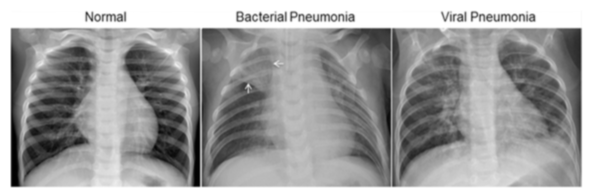


The Dataset original source is: https://data.mendeley.com/datasets/rscbjbr9sj/2

Under License: CC BY 4.0

Citation: http://www.cell.com/cell/fulltext/S0092-8674(18)30154-5

### Tools

Kaggle environemnt, 

## Important libaries for this project

To run this project the following is imported

In [1]:
import numpy as np
import pandas as pd 
import os
import pandas as pd
import random
import math
import PIL
import cv2
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model

2026-01-24 13:51:23.089626: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769262683.324084      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769262683.390927      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769262683.937963      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769262683.938032      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769262683.938036      17 computation_placer.cc:177] computation placer alr

In [2]:

def load_dataset_splits(base_path):
    """
    Reads the chest_xray directory and creates dataframes for train, test, and val.
    
    Structure expected:
    base_path/train/NORMAL/image.jpeg
    base_path/train/PNEUMONIA/image.jpeg
    """
    splits = ['train', 'test', 'val']
    dataframes = {}

    for split in splits:
        labels = []
        filepaths = []
        split_path = os.path.join(base_path, split)
        
        # Check if the split folder exists (val is sometimes empty or missing)
        if not os.path.exists(split_path):
            continue

        for folder in os.listdir(split_path):
            label_path = os.path.join(split_path, folder)
            
            if os.path.isdir(label_path):
                for image in os.listdir(label_path):
                    # Filter for image files only
                    if image.lower().endswith(('.jpeg', '.jpg', '.png')):
                        filepaths.append(os.path.join(label_path, image))
                        labels.append(folder)
        
        dataframes[split] = pd.DataFrame({
            'ImagePath': filepaths,
            'Label': labels
        })

    return dataframes.get('train'), dataframes.get('test'), dataframes.get('val')

In [3]:

# Usage (based on your Kaggle path)
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'
train_df, test_df, val_df = load_dataset_splits(base_path)

In [4]:
full_train_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

# Create a new 80/20 split 
# Use 'stratify' to ensure both NORMAL and PNEUMONIA are represented equally in both sets
train_df, val_df = train_test_split(
    full_train_df, 
    test_size=0.20, 
    random_state=42, 
    stratify=full_train_df['Label']
)

In [5]:
print(f"New Train Set: {len(train_df)} images")
print(f"New Validation Set: {len(val_df)} images")
print(f"Test Set (Unchanged): {len(test_df)} images")

New Train Set: 4185 images
New Validation Set: 1047 images
Test Set (Unchanged): 624 images


In [6]:
train_df.sample(10)

,ImagePath,Label
3331,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
2509,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1580,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4155,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
3281,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1687,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4917,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
212,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4492,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
1583,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA


In [7]:
train_df['Label'].value_counts()

Label
PNEUMONIA    3106
NORMAL       1079
Name: count, dtype: int64

class imbalance.  "Normal" class is much smaller than  "Pneumonia" class.

In [8]:
import matplotlib.pyplot as plt
import PIL.Image as Image

def show_random_samples(df, num=8):
    """
    Shows a random sample of images from the dataframe.
    """
    # Use pandas sample to get random rows safely regardless of index
    sample_df = df.sample(num)
    
    # Calculate grid size
    cols = 4
    rows = (num + cols - 1) // cols
    
    plt.figure(figsize=(20, rows * 5))
    
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        plt.subplot(rows, cols, i + 1)
        
        # Open and display image
        img = Image.open(row['ImagePath'])
        plt.imshow(img, cmap='gray')
        
        # Show label and original index in title
        plt.title(f"Diagnosis: {row['Label']}\n(Index: {idx})")
        plt.axis('off')
        
    plt.suptitle("Random Sample of the Dataset", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Test the function


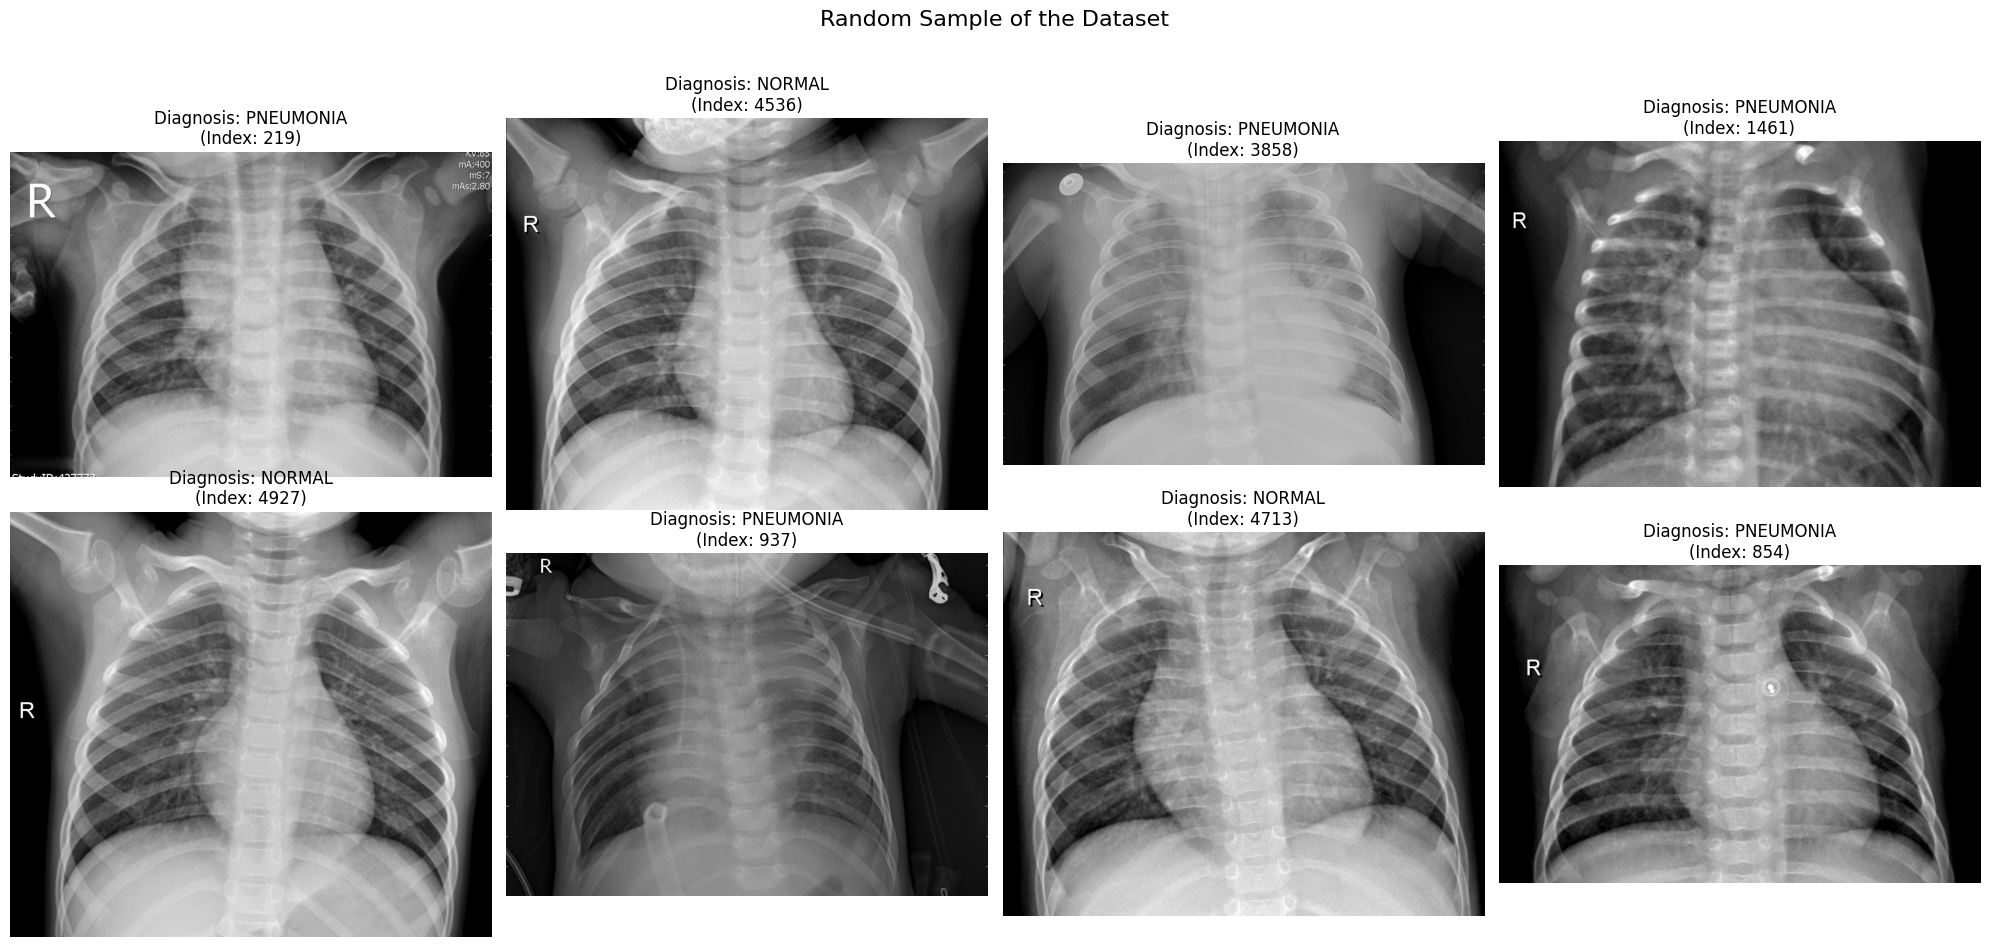

In [9]:
show_random_samples(train_df, 8)

The width of the images:  1300
The height of the images:  890
Shape (1300, 890)


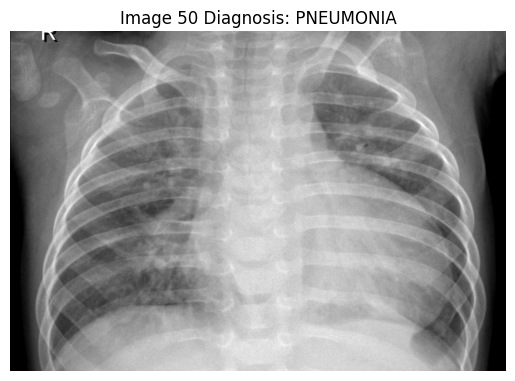

In [10]:
image_path =  train_df.loc[50, "ImagePath"]
image = PIL.Image.open(image_path)
plt.imshow(image, cmap='gray')
plt.title(f"Image {50} Diagnosis: {train_df.loc[50, 'Label']}")
plt.axis("off")
width, height = image.size
print("The width of the images: ", width)
print("The height of the images: ", height)
print("Shape", image.size)

The width of the images:  824
The height of the images:  568
Shape (824, 568)


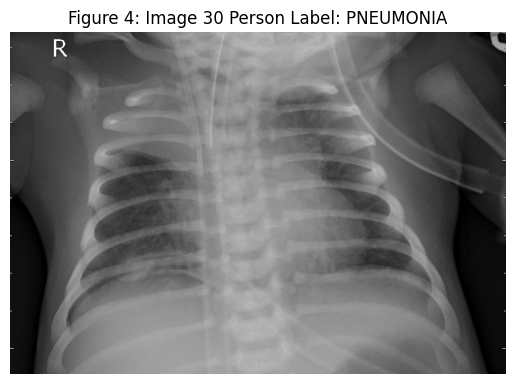

In [11]:
image_path =  train_df.loc[30, "ImagePath"]
image = PIL.Image.open(image_path)
plt.imshow(image, cmap='gray')
plt.title(f"Figure 4: Image {30} Person Label: {train_df.loc[30, 'Label']}")
plt.axis("off")
width, height = image.size
print("The width of the images: ", width)
print("The height of the images: ", height)
print("Shape", image.size)

In [12]:
image_sizes = []
aspect_ratios = []

for image_path in train_df['ImagePath']:
    image = PIL.Image.open(image_path)
    width, height = image.size
    image_sizes.append(width * height)
    aspect_ratios.append(width / height)

Text(0, 0.5, 'Frequency')

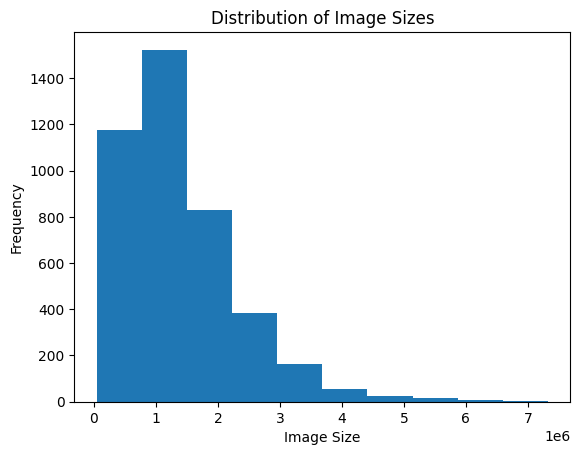

In [13]:
plt.hist(image_sizes, label="Image Size")
plt.title("Distribution of Image Sizes")
plt.xlabel("Image Size")
plt.ylabel("Frequency")

- Most images are quite large

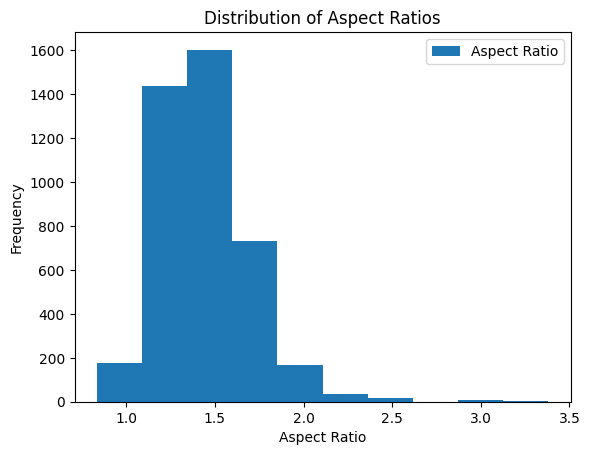

In [14]:
plt.hist(aspect_ratios, label="Aspect Ratio")
plt.title("Distribution of Aspect Ratios")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.legend()

Most images are not square; they are roughly 1.3 to 1.6 (wider than they are tall).

In [15]:

IMG_SIZE = 224 # Standard for many CNN architectures

def preprocess_image(path):
    # Load in Grayscale (standard for X-rays)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    # Standard resize (it will stretch/squash slightly, which is okay here)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Normalization: X-rays have varying brightness/contrast
    # This scales pixels to [0, 1]
    img = img / 255.0
    
    # Add channel dimension for the CNN (Height, Width, 1)
    img = np.expand_dims(img, axis=-1)
    
    return img

<function matplotlib.pyplot.show(close=None, block=None)>

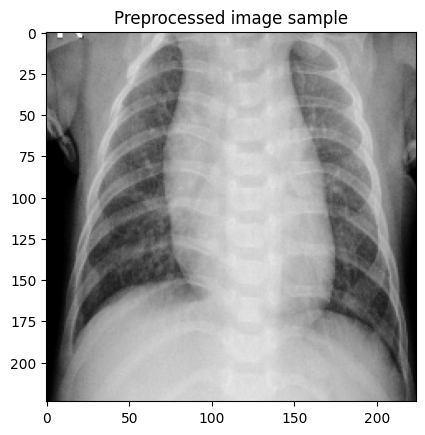

In [16]:
plt.imshow(preprocess_image(train_df.iloc[100]['ImagePath']), cmap="gray")
plt.title("Preprocessed image sample")
plt.show

In [17]:
le = LabelEncoder() ## will be using the same encoder

In [18]:
def prepare_dataset(df, encoder, is_training=True):
    """
    Final wrapper to process both labels and images for a specific split.
    
    Args:
        df (pd.DataFrame): The split dataframe (train, val, or test).
        encoder (LabelEncoder): The fitted or to-be-fitted LabelEncoder.
        is_training (bool): If True, fits the encoder. If False, only transforms.
        
    Returns:
        X (np.array): Preprocessed image array.
        y (np.array): Encoded label array.
    """
    # 1. Process Labels
    if is_training:
        df['Label_Num'] = encoder.fit_transform(df['Label'])
    else:
        df['Label_Num'] = encoder.transform(df['Label'])
    
    # 2. Process Images
    num_samples = len(df)
    preprocessed_images = []
    
    for i in range(num_samples):
        img_path = df['ImagePath'].iloc[i]
        image = preprocess_image(img_path) 
        preprocessed_images.append(image)
    
    X = np.array(preprocessed_images)
    y = np.array(df['Label_Num'])
    
    return X, y

In [19]:
# Prepare each split 
X_train, y_train = prepare_dataset(train_df, le, is_training=True)
X_val, y_val     = prepare_dataset(val_df, le, is_training=False)
X_test, y_test   = prepare_dataset(test_df, le, is_training=False)

In [20]:
print(f" Train Set: {X_train.shape}") 

 Train Set: (4185, 224, 224, 1)


In [21]:
print(f" Validation set: {X_val.shape}") 

 Validation set: (1047, 224, 224, 1)


In [22]:
print(f" Test Set Shape: {X_test.shape}") 

 Test Set Shape: (624, 224, 224, 1)


The current split is 70% train, 20% test and 10% validation


### Main Task:
- The main task is to Train a CNN model. 
- The design is either my own architecture or use existing architecture. 
- the architecture details is specified used either you designed it or cite existing literature on what did you use.

#### Requested model

In [23]:
def build_required_model(input_shape=(224, 224, 1)):
    model = models.Sequential()

    # 1. Convolutional Layer with non-overlapping filters
    # Kernel size 4x4 and Stride 4 ensures no overlap
    model.add(layers.Conv2D(32, kernel_size=(4, 4), strides=(4, 4), 
                            activation='relu', input_shape=input_shape))

    # 2. Average Pooling Layer
    model.add(layers.AveragePooling2D(pool_size=(2, 2)))

    # 3. Fully Connected NN
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5)) 
    
    # Output layer for Binary Classification (Normal vs Pneumonia)
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

In [24]:
# Initialize the model
model = build_required_model()

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-24 13:52:58.785530: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 56, 56, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 28, 28, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,212,065 (12.25 MB)

 Trainable params: 3,212,065 (12.25 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(np.array(X_train), y_train, 
                            validation_data=(np.array(X_val), y_val), 
                    epochs=25, batch_size=32)

Epoch 1/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7611 - loss: 0.5102 - val_accuracy: 0.9312 - val_loss: 0.2154
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.8914 - loss: 0.2571 - val_accuracy: 0.9456 - val_loss: 0.1704
Epoch 3/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9202 - loss: 0.1972 - val_accuracy: 0.9446 - val_loss: 0.1547
Epoch 4/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9327 - loss: 0.1779 - val_accuracy: 0.9561 - val_loss: 0.1474
Epoch 5/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9422 - loss: 0.1634 - val_accuracy: 0.9589 - val_loss: 0.1092
Epoch 6/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9402 - loss: 0.1489 - val_accuracy: 0.9580 - val_loss: 0.1074
Epoch 7/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9511 - loss: 0.1367 - val_accuracy: 0.9608 - val_loss: 0.1032
Epoch 8/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9494 - loss: 0.1284 - val_acc

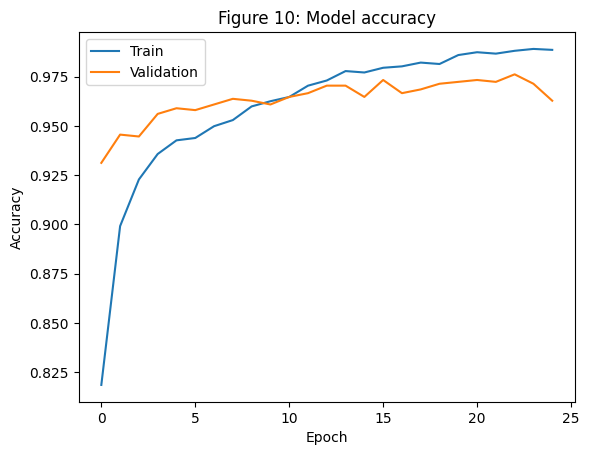

In [26]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Figure 10: Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

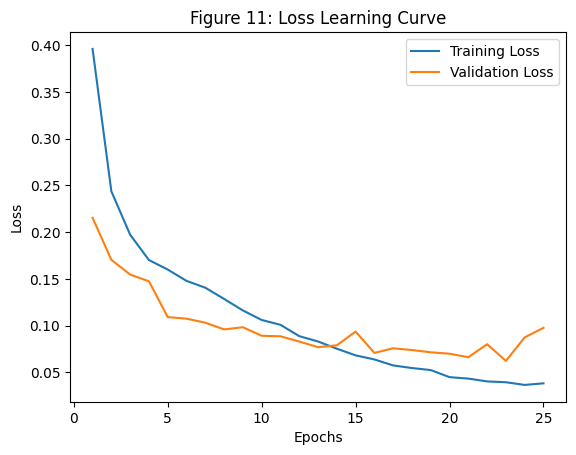

In [27]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(training_loss) + 1)

plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validation_loss, label='Validation Loss')
plt.title('Figure 11: Loss Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
model.save("pneumonia_model.keras")
reconstructed_model = load_model("pneumonia_model.keras")
reconstructed_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

test_loss, test_acc = reconstructed_model.evaluate(X_test, y_test)
print(f"Final Aggregated Test Accuracy: {test_acc*100:.3f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9079 - loss: 0.6613
Final Aggregated Test Accuracy: 69.391%


The required model results in overfitting

In [29]:
def build_proposed_model(input_shape=(224, 224, 1)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Classifier
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [30]:
model2 = build_proposed_model()

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history2 = model2.fit( X_train, y_train, validation_data=(X_val, y_val),
    epochs=50, batch_size=32,shuffle=True)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.8046 - loss: 0.4260 - val_accuracy: 0.9589 - val_loss: 0.0971
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9506 - loss: 0.1349 - val_accuracy: 0.9484 - val_loss: 0.1210
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.9505 - loss: 0.1304 - val_accuracy: 0.9704 - val_loss: 0.0726
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9763 - loss: 0.0695 - val_accuracy: 0.9752 - val_loss: 0.0707
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9763 - loss: 0.0623 - val_accuracy: 0.9780 - val_loss: 0.0760
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.9723 - loss: 0.0752 - val_accuracy: 0.9780 - val_loss: 0.0566
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.9831 - loss: 0.0488 - val_accuracy: 0.9742 - val_loss: 0.0601
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.9842 - loss: 0.0387 - val_accu

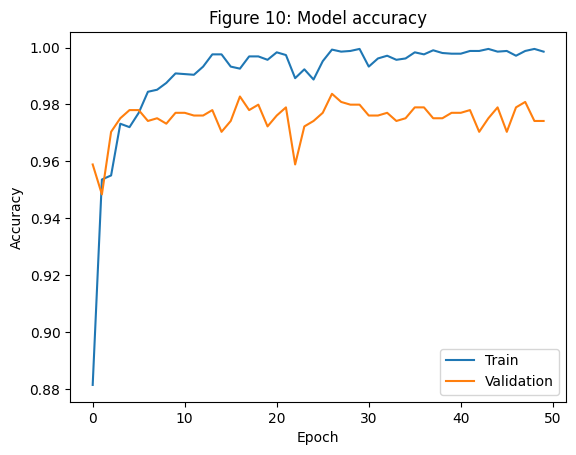

In [32]:
plt.figure()
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.title('Figure 10: Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

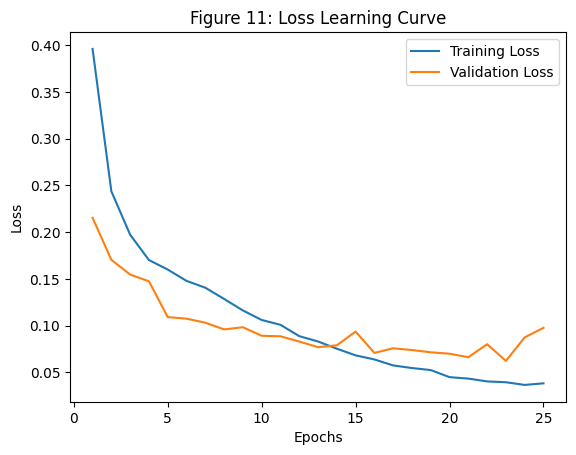

In [33]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(training_loss) + 1)

plt.plot(epochs, training_loss, label='Training Loss')
plt.plot(epochs, validation_loss, label='Validation Loss')
plt.title('Figure 11: Loss Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [34]:
model2.save("pneumonia_model_2.keras")
reconstructed_model_2 = load_model("pneumonia_model_2.keras")
reconstructed_model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
test_loss_2, test_acc_2 = reconstructed_model_2.evaluate(X_test, y_test)
print(f"Final Aggregated Test Accuracy: {test_acc*100:.3f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 457ms/step - accuracy: 0.9224 - loss: 1.6097
Final Aggregated Test Accuracy: 69.391%



### Outline
In this Report the results and experiments are shown, provided the following: 

- A: The architecture used to train CNNs.
- B: performance Comparison of the new model against a CNN model with the following specification: 
    - 1 convolutional layer (non-overlapping filters), 
    - 1 average pooling layer, 
    - fully connected NN.

- C: Performance Report of both models.: 
    - the Accuracy,
    - Precision, 
    - Recall, 
    - F1-Score of

- D: Class confusion matrix
    Provide the Class confusion matrix of the classification output for both classifiers.

- E: Insights and interpretations of the results (discussions).

- F: the code


## Refrences:
- [1] Dataset: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia 
- [2] https://www.mayoclinic.org/diseases-conditions/pneumonia/symptoms-causes/syc-20354204